# Phase 4.1 Pipeline

Train the generalization-focused model set and review results.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

## Train models

In [2]:
!python "phase41_train_pipeline.py" --input "../phase_4/results/phase4_dataset.csv" --results-dir "results" --artifacts-dir "artifacts" --drop-no-result

Phase 4.1 training: 100%|█████| 3/3 [02:45<00:00, 55.13s/model, extra_trees_gen]
Saved results to: results
Saved artifacts to: artifacts
Best model: xgb_gen
Best model test metrics: {"accuracy": 0.5571, "f1_weighted": 0.491, "f1_macro": 0.4806, "fit_gap": -0.0106, "gen_score": 0.5571}


## Review outputs

In [3]:
results_dir = Path("results")
artifacts_dir = Path("artifacts")

metrics = pd.read_csv(results_dir / "phase41_model_comparison_metrics.csv")
meta = json.loads((artifacts_dir / "phase41_model_metadata.json").read_text(encoding="utf-8"))

display(metrics)
print("Best model:", meta.get("best_model"))
print("Best model params:", meta.get("best_model_params"))
meta.get("best_model_test_metrics", {})

,model,train_accuracy,test_accuracy,train_f1_weighted,test_f1_weighted,test_f1_macro,test_balanced_accuracy,top2_accuracy,top3_accuracy,calibration_ece,fit_gap_weighted_f1,generalization_score,best_cv_accuracy
0,xgb_gen,0.525910,0.557143,0.480325,0.490962,0.480630,0.579192,0.785714,0.785714,0.241788,-0.010636,0.557143,0.523702
1,extra_trees_gen,0.782800,0.585714,0.778933,0.579083,0.546316,0.563990,1.000000,1.000000,0.283193,0.199850,0.545744,0.547939
2,rf_gen,0.687982,0.557143,0.674964,0.542139,0.525459,0.550657,0.957143,0.985714,0.254241,0.132825,0.530578,0.541327


Best model: xgb_gen
Best model params: {'model__subsample': 0.75, 'model__reg_lambda': 18.0, 'model__reg_alpha': 8.0, 'model__n_estimators': 140, 'model__min_child_weight': 14, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__gamma': 2.5, 'model__colsample_bytree': 0.55}


{'train_accuracy': 0.525909592061742,
 'test_accuracy': 0.5571428571428572,
 'train_f1_weighted': 0.48032549379813433,
 'test_f1_weighted': 0.4909616020321172,
 'test_f1_macro': 0.48062964316161255,
 'test_balanced_accuracy': 0.5791919191919193,
 'top2_accuracy': 0.7857142857142857,
 'top3_accuracy': 0.7857142857142857,
 'calibration_ece': 0.24178788193634582,
 'fit_gap_weighted_f1': -0.010636108233982866,
 'generalization_score': 0.5571428571428572,
 'best_cv_accuracy': 0.5237022645862425}

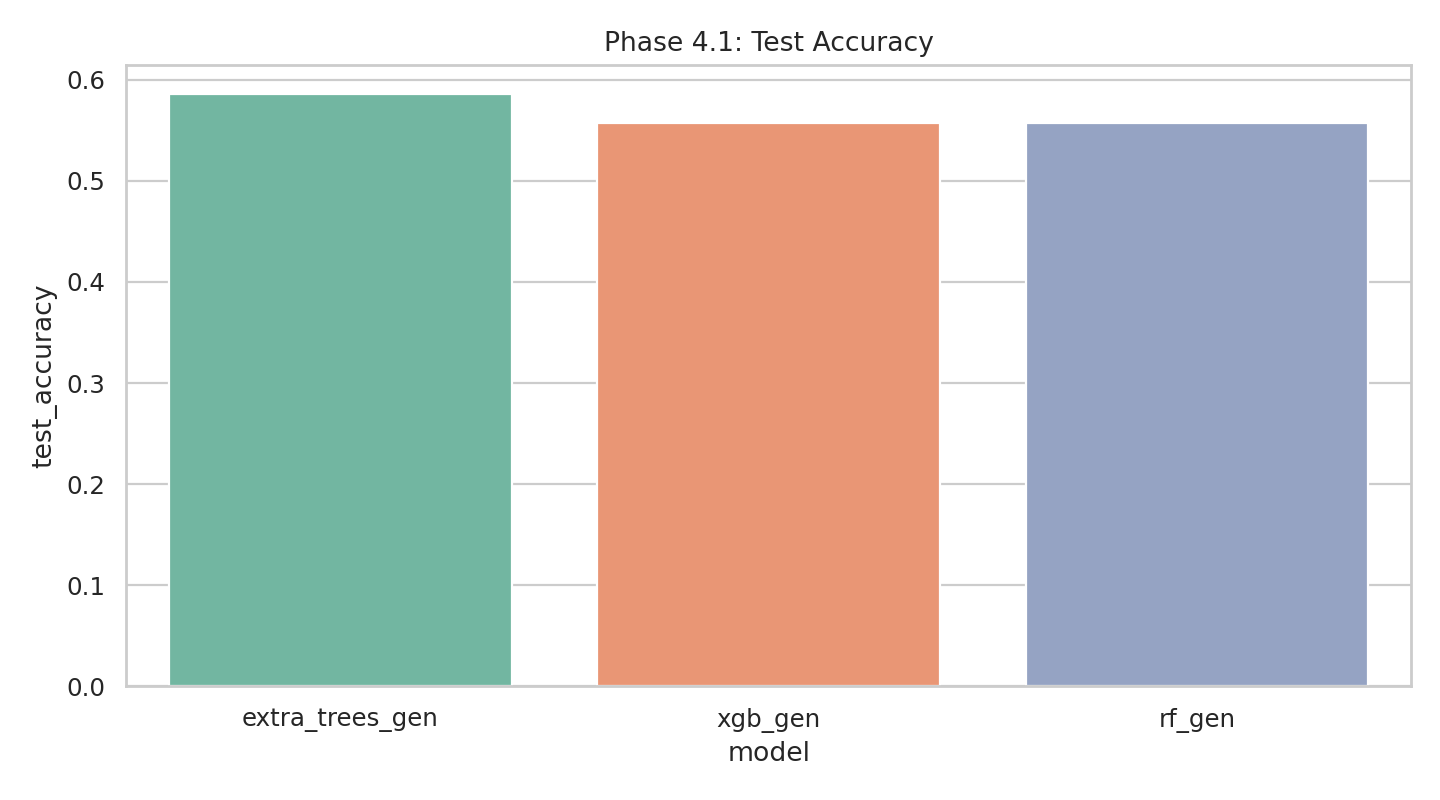

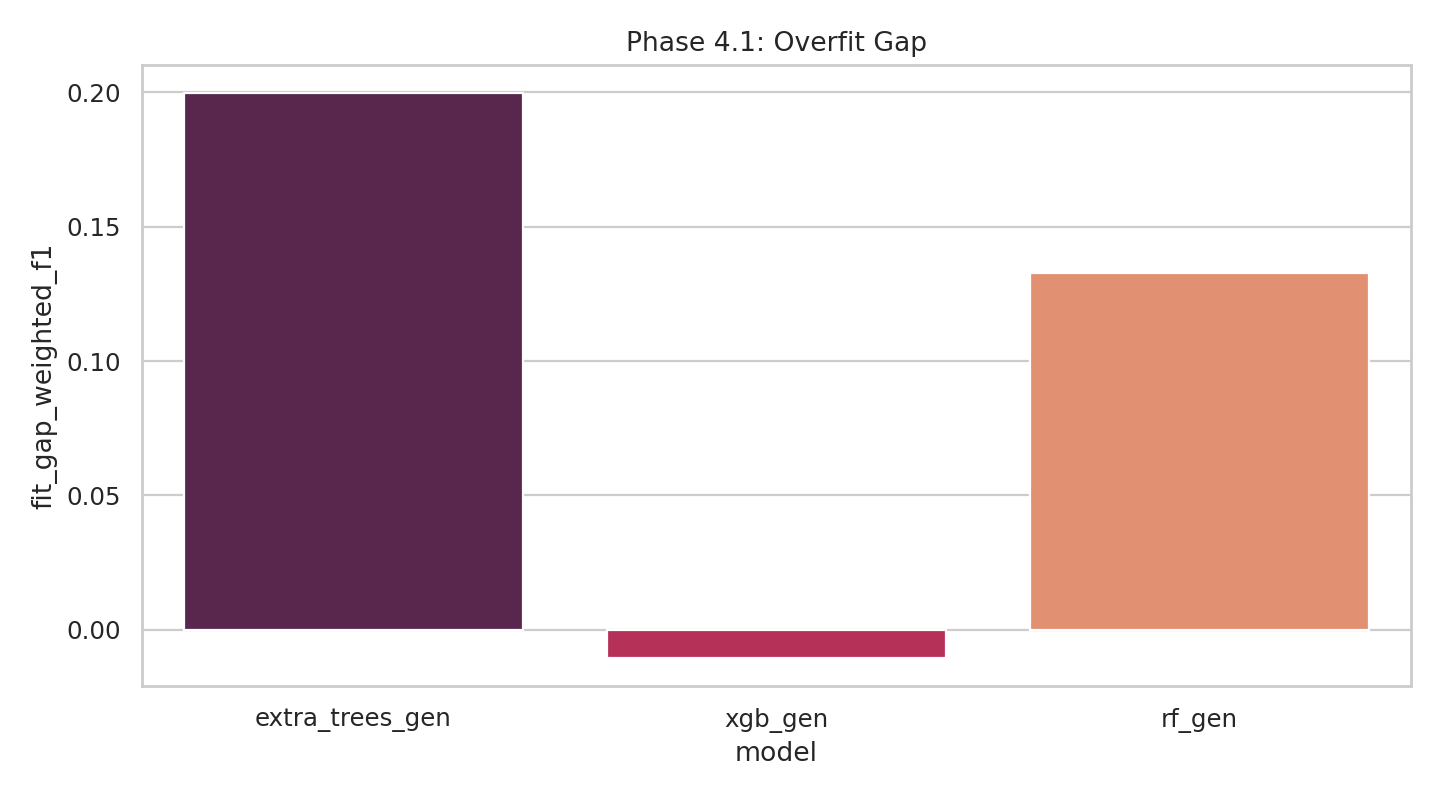

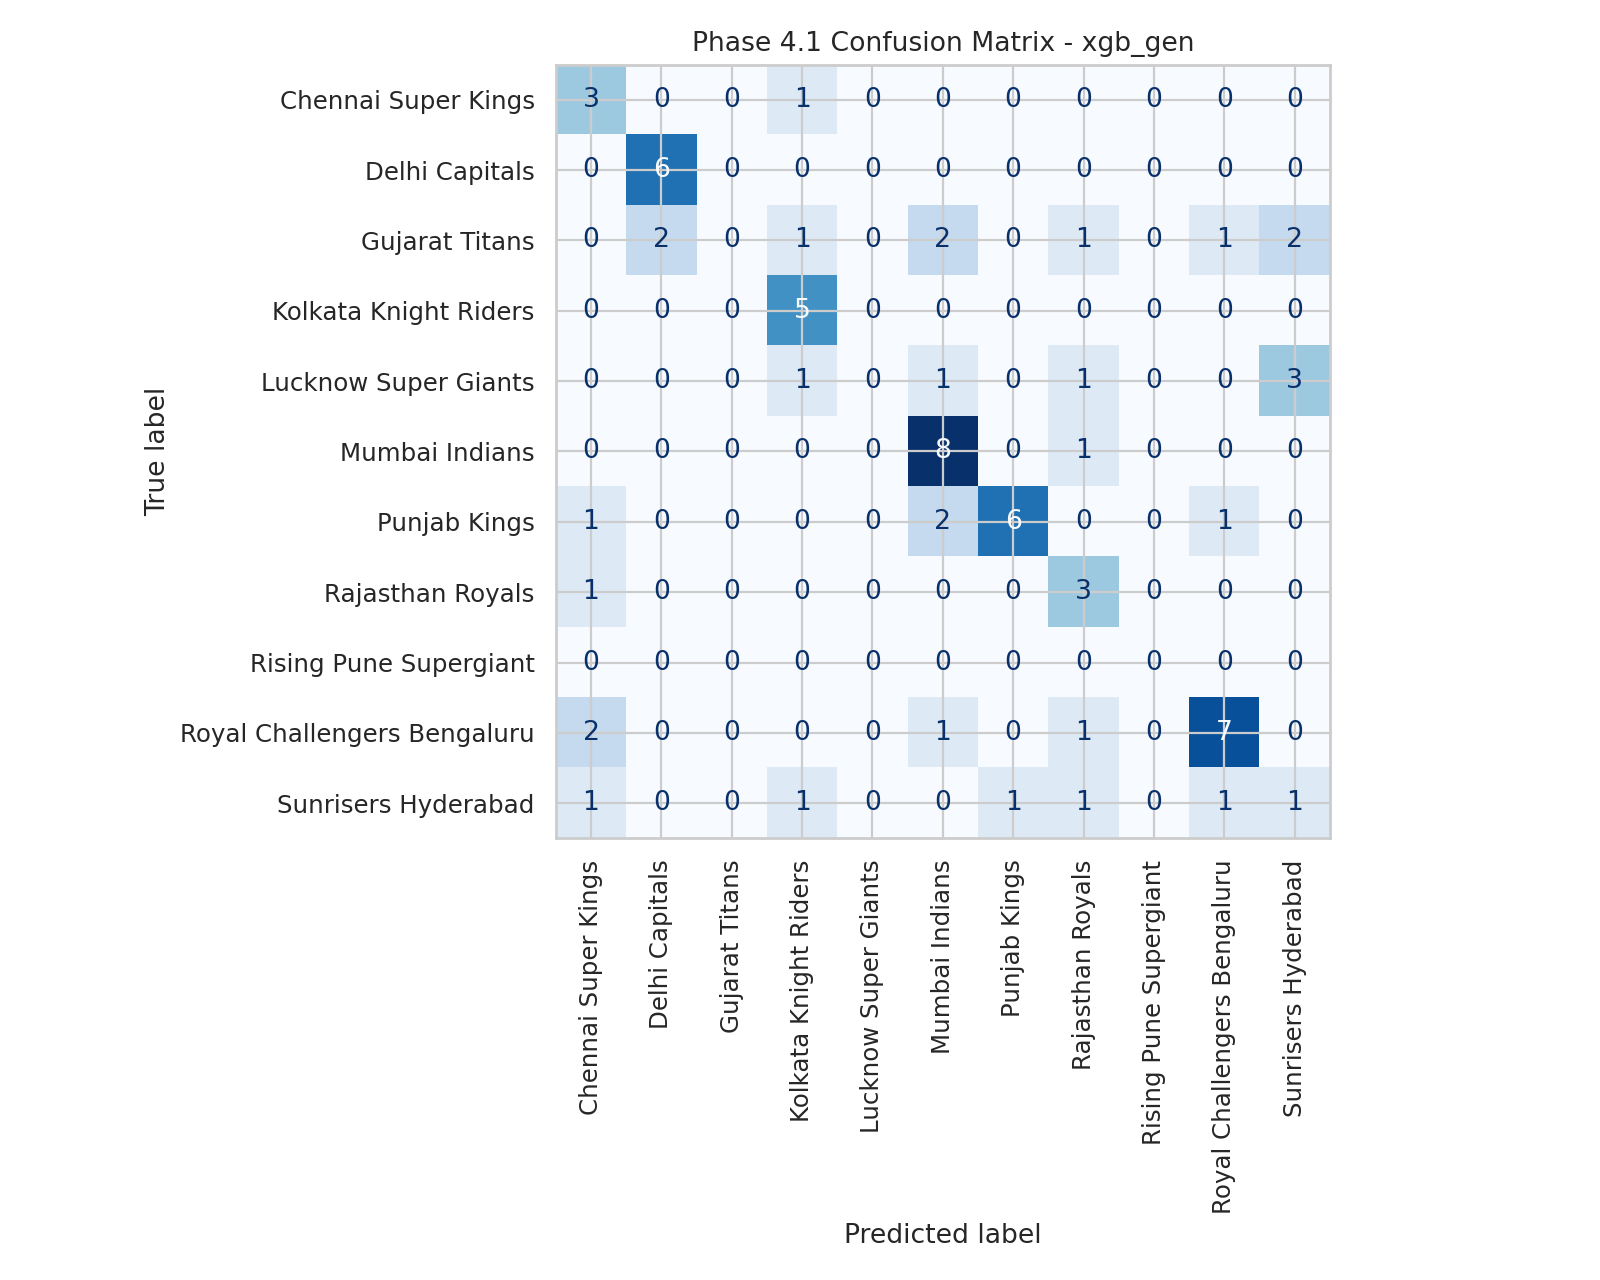

In [4]:
display(Image(filename=str(results_dir / "phase41_test_accuracy.png")))
display(Image(filename=str(results_dir / "phase41_overfit_gap.png")))
display(Image(filename=str(results_dir / "phase41_best_confusion_matrix.png")))